# Tratamento dos dados

## Une as tabelas

In [1]:
import pandas as pd

# Ler os arquivos CSV
articles_df = pd.read_csv('articles.csv')
data_extraction_df = pd.read_csv('data_extraction.csv')

outputCsv = 'merged_articles_data.csv'

# Renomear colunas para facilitar o merge
data_extraction_df = data_extraction_df.rename(columns={'article': 'title'})

# Converter colunas de data para datetime (se necessário)
articles_df['year'] = pd.to_numeric(articles_df['year'], errors='coerce')
data_extraction_df['Ano'] = pd.to_numeric(data_extraction_df['Ano'], errors='coerce')

# Fazer o merge dos dataframes
merged_df = pd.merge(
    articles_df,  # Colunas que queremos do articles.csv
    data_extraction_df,
    on='title',
    how='outer'
)

# Preencher anos faltantes: usar o ano do data_extraction quando não houver no articles
merged_df['year'] = merged_df['year'].fillna(merged_df['Ano'])

# Remover a coluna Ano auxiliar
merged_df = merged_df.drop(columns=['Ano'])

# Renomear coluna year para ano para manter consistência
merged_df = merged_df.rename(columns={'year': 'ano'})

# Reordenar colunas (opcional)
cols = ['title', 'ano'] + [col for col in merged_df.columns if col not in ['title', 'ano']]
merged_df = merged_df[cols]

# Salvar o resultado em um novo arquivo CSV
merged_df.to_csv(outputCsv, index=False)

print("Arquivo criado com sucesso!")
print(f"Total de registros: {len(merged_df)}")

ModuleNotFoundError: No module named 'pandas'

## Desmarca inputs e interações redundantes

In [18]:
import pandas as pd

# Load the dataset
df = pd.read_csv('transformed_data.csv')

# Filter for "Accepted" status
accepted_df = df[df['status'] == 'Accepted'].copy()

# Save accepted_data.csv
accepted_df.to_csv('accepted_data.csv', index=False)
print("Criado accepted_data.csv com as linhas 'Accepted'.")

# Create accepted_data_adapted.csv
adapted_df = accepted_df.copy()

# --- Apply filters for accepted_data_adapted.csv ---

# Function to clean 'Tecnologia do input'
def clean_input_tech(text):
    if not isinstance(text, str):
        return text
    
    values = [v.strip() for v in text.split(',')]
    
    # Handle the Sensor-Assisted-Vision-Based and Vision-Based co-occurrence first
    if 'Sensor-Assisted-Vision-Based' in values and 'Vision-Based' in values:
        values_to_keep = [v for v in values if v != 'Vision-Based']
        
        # Then, apply the rename for any remaining 'Vision-Based' (which shouldn't happen here, but for robustness)
        cleaned_values = ['Pure-Vision-Based' if val == 'Vision-Based' else val for val in values_to_keep]
        return ', '.join(sorted(list(set(cleaned_values))))

    # Now, handle the general Vision-Based to Pure-Vision-Based renaming
    cleaned_values = ['Pure-Vision-Based' if val == 'Vision-Based' else val for val in values]
    return ', '.join(sorted(list(set(cleaned_values))))

adapted_df['Tecnologia do input'] = adapted_df['Tecnologia do input'].astype(str).apply(clean_input_tech)


# Function to clean 'Tipo de interação'
def clean_interaction_type(text):
    if not isinstance(text, str):
        return text
    
    values = [v.strip() for v in text.split(',')]

    if 'Multi-touch' in values and 'Touch' in values:
        values_to_keep = [v for v in values if v != 'Touch']
        return ', '.join(sorted(list(set(values_to_keep))))
    return ', '.join(sorted(list(set(values))))

adapted_df['Tipo de interação'] = adapted_df['Tipo de interação'].astype(str).apply(clean_interaction_type)

def clean_collaboration(text):
    if not isinstance(text, str):
        return text
    
    values = [v.strip() for v in text.split(',')]
    
    # Rule 1: If "Colaboração presencial" and "Usuário Único", keep only "Colaboração presencial"
    if 'Colaboração presencial' in values and 'Usuário Único' in values:
        values_to_keep = [v for v in values if v != 'Usuário Único']
        return ', '.join(sorted(list(set(values_to_keep))))
    
    # Rule 2: If "Colaboração presencial" and "Colaboração remota", keep only "Colaboração remota"
    # This rule should be checked after the first one, as "Colaboração presencial" might be involved in both.
    # The order here is important. If both Colaboração presencial and Colaboração remota are present, Colaboração remota should take precedence.
    if 'Colaboração presencial' in values and 'Colaboração remota' in values:
        values_to_keep = [v for v in values if v != 'Colaboração presencial']
        return ', '.join(sorted(list(set(values_to_keep))))
        
    return ', '.join(sorted(list(set(values))))

adapted_df['Suporte à colaboração'] = adapted_df['Suporte à colaboração'].astype(str).apply(clean_collaboration)

# Save accepted_data_adapted.csv
adapted_df.to_csv('accepted_data_adapted.csv', index=False)
print("Criado accepted_data_adapted.csv com os filtros aplicados.")

Criado accepted_data.csv com as linhas 'Accepted'.
Criado accepted_data_adapted.csv com os filtros aplicados.


## Corrige termos

In [ ]:
import pandas as pd

inputCsv = 'merged_articles_data.csv'
outputCsv = 'transformed_data.csv'

# Dicionário de traduções
translation_dict = {
    # Tecnologias de Display
    'Embutido': 'Embedded',
    'Projetor superior': 'Front-Projected',
    'Projetor inferior': 'Rear-Projected',

    # Tecnologias de Input
    'Caneta': 'Pen',
    'Ondas sonoras': 'Sound-Based',
    'Sensor infravermelho': 'Sensor-Assisted-Vision-Based',
    'Tokens tangíveis': 'Tangible-Tokens',
    'Toque': 'Electrical-Based',
    'Visão computacional': 'Vision-Based',

    # Critérios de seleção
    'Incomplete works, posters, summaries': 'Incomplete works, posters, summaries, etc',
    'Interfaces with only mouse/keyboard interaction': 'Interfaces without direct interaction',
    'The digital tabletop interface was not tangible': 'Study was not about digital tabletops',
}

def translate_terms(text):
    if pd.isna(text):
        return text
    for pt, en in translation_dict.items():
        text = text.replace(pt, en)
    return text

# Carregar os dados (substitua pelo seu arquivo real)
df = pd.read_csv(inputCsv)

# Aplicar traduções nas colunas relevantes
df['Tecnologia do display'] = df['Tecnologia do display'].apply(translate_terms)
df['Tecnologia do input'] = df['Tecnologia do input'].apply(translate_terms)
df['selection_criteria'] = df['selection_criteria'].apply(translate_terms)

# Salvar o resultado (substitua pelo nome desejado)
df.to_csv(outputCsv, index=False)

print("Transformação concluída! Resultado salvo em " + outputCsv)
print("\nAmostra dos dados transformados:")
print(df.head())

Transformação concluída! Resultado salvo em transformed_data.csv

Amostra dos dados transformados:
                                               title   ano  \
0  "All in the Same Boat": Tradeoffs of Voice Ass...  2020   
1  "Callout Bubble Saved My Life": Workspace Awar...  2015   
2  "Dinner Party" sociable interfaces in a tablet...  2011   
3  "Local Remote" Collaboration: Applying Remote ...  2015   
4                   1.24 - Augmented Reality and GIS  2018   

                source                                 selection_criteria  \
0  ACM Digital Library              Study was not about digital tabletops   
1  ACM Digital Library              Study was not about digital tabletops   
2  ACM Digital Library  Study describing digital tabletop application ...   
3  ACM Digital Library          Incomplete works, posters, summaries, etc   
4       Science@Direct         Articles that omits the tabletop technique   

     status comments Tecnologia do display  \
0  Rejected      Na

## Tabela aceitos por base de dados


In [10]:
import pandas as pd

# Load the original CSV
df = pd.read_csv('transformed_data.csv')

# Group and count
summary = df.groupby('source')['status'].value_counts().unstack(fill_value=0)

# Prepare columns
summary['Aceitos'] = summary.get('Accepted', 0)
summary['Rejeitados'] = summary.get('Rejected', 0) + summary.get('Duplicated', 0) + summary.get('Unclassified', 0)
summary['Resultados'] = summary['Aceitos'] + summary['Rejeitados']

# Reorder and rename
final_table = summary[['Resultados', 'Aceitos', 'Rejeitados']].reset_index()
final_table.columns = ['Base de dados', 'Resultados', 'Aceitos', 'Rejeitados']

# Add total row
total_row = pd.DataFrame([{
    'Base de dados': 'Total',
    'Resultados': final_table['Resultados'].sum(),
    'Aceitos': final_table['Aceitos'].sum(),
    'Rejeitados': final_table['Rejeitados'].sum()
}])

final_table = pd.concat([final_table, total_row], ignore_index=True)

# Optionally save to CSV
final_table.to_csv('summary_with_totals.csv', index=False)

print(final_table)


          Base de dados  Resultados  Aceitos  Rejeitados
0   ACM Digital Library         707      275         432
1  IEEE Digital Library         189       88         101
2        Science@Direct          91       30          61
3                Scopus         178       54         124
4         Springer Link         350      109         241
5                 Total        1515      556         959


# Gráficos

## Artigos aceitos por ano

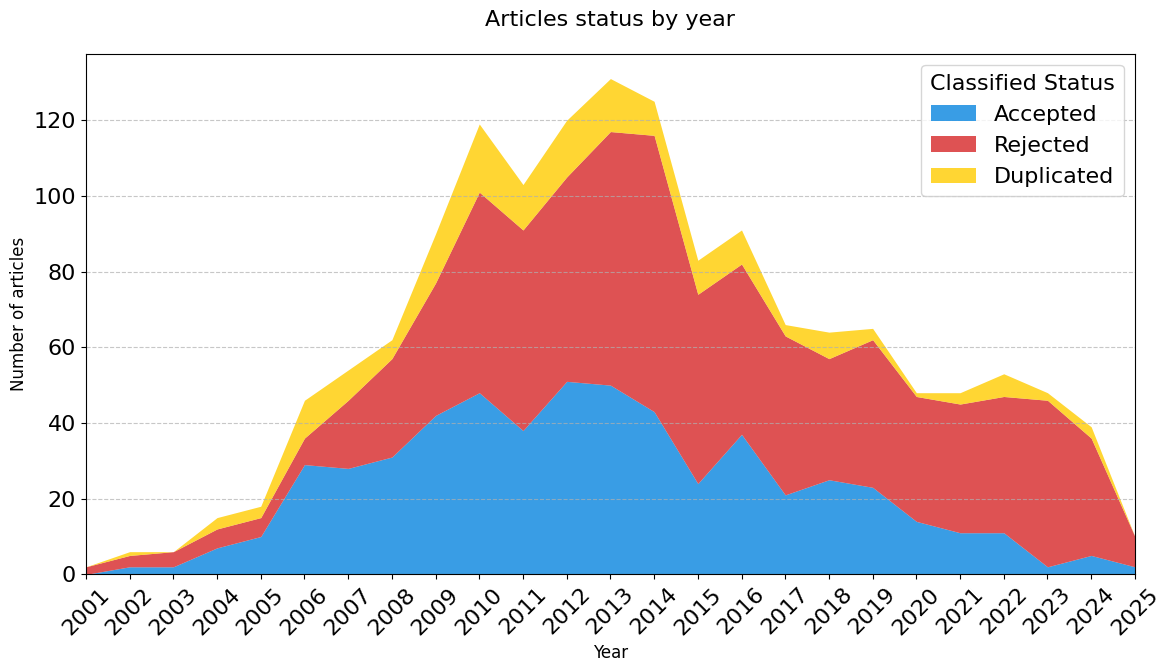

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Necessário para np.arange

plt.rcParams.update({'font.size': 16})

# --- Funções Auxiliares (mantidas para consistência de cores) ---
def get_status_color(status):
    """Retorna a cor base para cada status."""
    return {
        'Accepted': "#0785df",  # Azul
        'Rejected': '#d62728',  # Vermelho mais vibrante
        'Duplicated': '#ffcc00' # Amarelo
    }.get(status, '#999999')

# --- Início do seu Código Modificado para o Gráfico de Linha ---

# Carregar os dados
articles_df = pd.read_csv('articles.csv')

# --- Pré-processamento e Agregação de Dados ---

# Garantir que a coluna 'year' existe e é numérica
if 'year' not in articles_df.columns:
    # Se 'publication_date' for o nome da sua coluna de data, ajuste aqui
    if 'publication_date' in articles_df.columns:
        articles_df['year'] = pd.to_datetime(articles_df['publication_date'], errors='coerce').dt.year
    else:
        print("Erro: Nenhuma coluna 'year' ou 'publication_date' encontrada.")
        exit()

# Remover linhas com ano inválido (NaN)
articles_df.dropna(subset=['year'], inplace=True)
articles_df['year'] = articles_df['year'].astype(int)

# Filtrar o outlier de 1983, se ele ainda estiver presente nos seus dados e você quiser removê-lo especificamente para este gráfico
articles_df_filtered = articles_df[articles_df['year'] != 1983].copy()


# Contar a ocorrência de cada status por ano
# Usamos pivot_table para ter uma estrutura de DataFrame limpa com anos como índice
status_by_year = articles_df_filtered.pivot_table(
    index='year',
    columns='status',
    aggfunc='size',
    fill_value=0
)

# Garantir que todas as colunas de status esperadas existem, preenchendo com zero se ausentes
for status in ['Accepted', 'Rejected', 'Duplicated']:
    if status not in status_by_year.columns:
        status_by_year[status] = 0

# A ordem das colunas é importante para o empilhamento da área:
# Queremos que 'Accepted' e 'Rejected' e 'Duplicated' sejam as camadas base
# e 'Total' (que será adicionado) seja a camada superior se quisermos plotá-la separadamente,
# mas para um gráfico de área empilhada, o "total" é a soma das camadas.
# A ordem das colunas determinará a ordem das camadas empilhadas.
# Vamos colocar na ordem que faz mais sentido visualmente ou analiticamente.
status_by_year = status_by_year[['Accepted', 'Rejected', 'Duplicated']]

# Calculando o total por ano (soma das colunas de status)
status_by_year['Total'] = status_by_year.sum(axis=1)

# --- Configurar o Gráfico de Área Empilhada ---

plt.figure(figsize=(12, 7)) # Ajustei o tamanho para melhor visualização

# Definindo as cores para cada status usando a função auxiliar
colors = [get_status_color('Accepted'), get_status_color('Rejected'), get_status_color('Duplicated')]
labels = ['Accepted', 'Rejected', 'Duplicated']

# Plotar o gráfico de área empilhada
# O método .plot.area() do Pandas é ideal para isso
# Ele automaticamente empilha as colunas que você seleciona
status_by_year[labels].plot.area(
    ax=plt.gca(), # Usa o eixo atual
    color=colors,
    alpha=0.8, # Adiciona transparência para melhor visualização das camadas
    linewidth=0 # Linha entre as áreas, geralmente 0 para áreas preenchidas
)

# Adicionar rótulos e título
plt.title('Articles status by year', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of articles', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Configurar o eixo X para mostrar todos os anos com dados e rotacioná-los
years = status_by_year.index
plt.xticks(years, rotation=45)
# Ajustar limites do eixo X para ter um pequeno espaçamento nas bordas
plt.xlim(years.min(), years.max())

# Adicionar legenda
plt.legend(title="Classified Status")

plt.tight_layout()
plt.savefig('status_distribution_over_years_stacked_area.png', dpi=300)
plt.show()

# --- Fim do Código Modificado ---

## Razões de aceite/rejeite

status
Rejected        800
Accepted        556
Duplicated      157
Unclassified      2
Name: count, dtype: int64


,Study describing digital tabletop application that mentions the hardware used,Study describing digital tabletop techniques,Study evaluating digital tabletop techniques,Articles that omits the tabletop technique,Study was not about digital tabletops,"Incomplete works, posters, summaries, etc",Interfaces without direct interaction,The study was not written in English,Duplicate papers
Accepted,317.0,179.0,60.0,0.0,0.0,0.0,0.0,0.0,0.0
Rejected,0.0,0.0,0.0,356.0,343.0,74.0,14.0,4.0,0.0
Duplicated,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0


Gerando gráfico de pizza da distribuição por status...


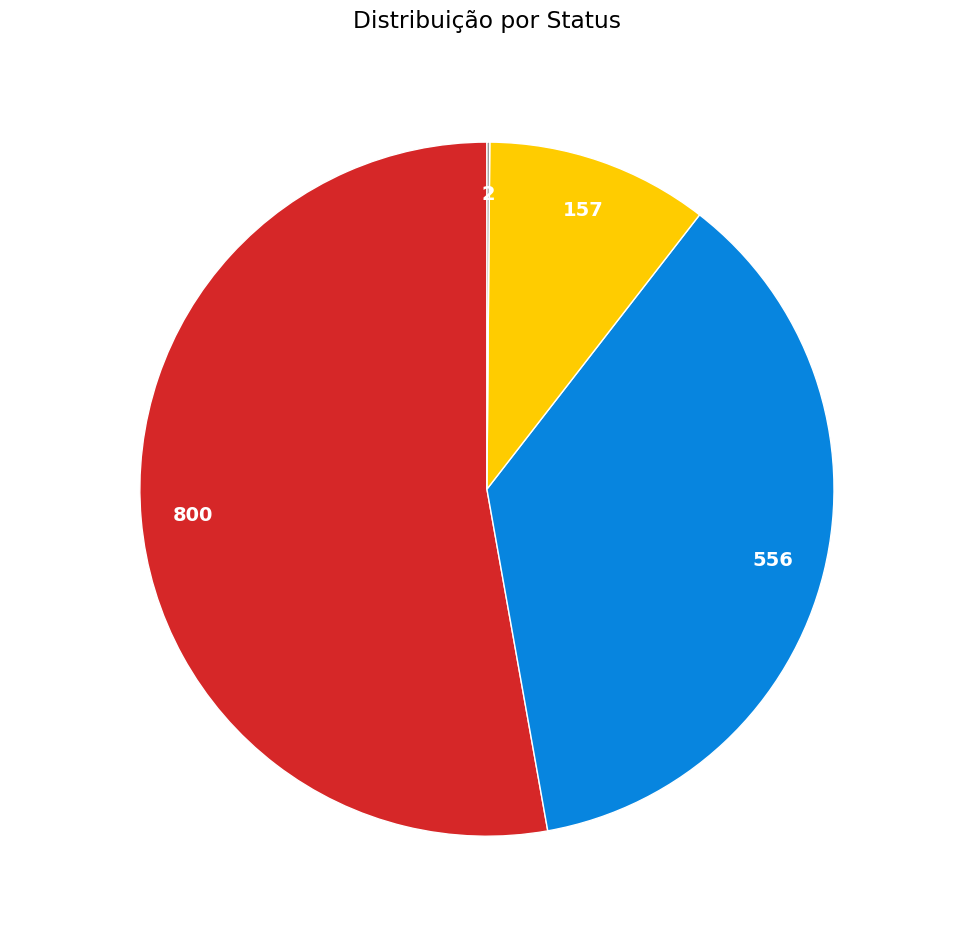

Gerando gráfico de barras dos motivos por status...


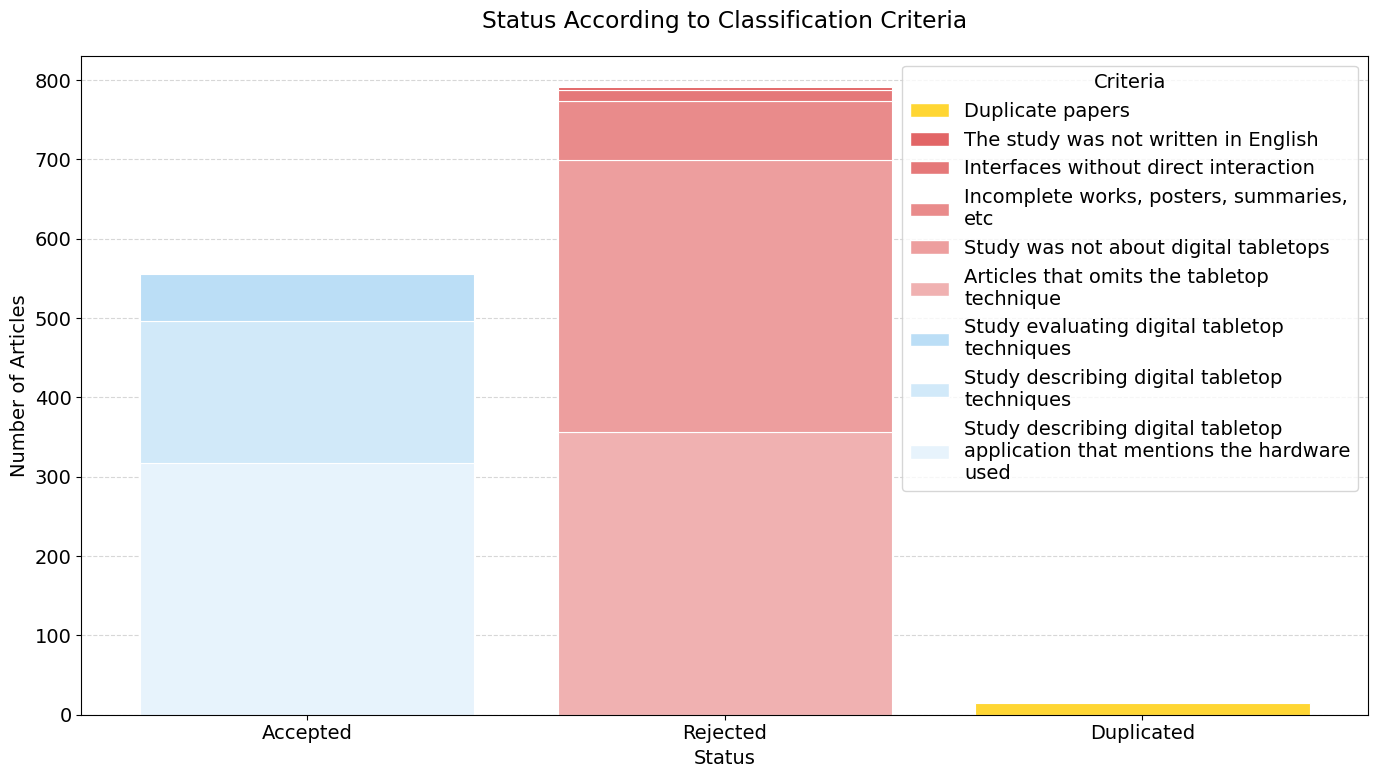

Gerando gráfico de linha da evolução dos critérios ao longo dos anos...


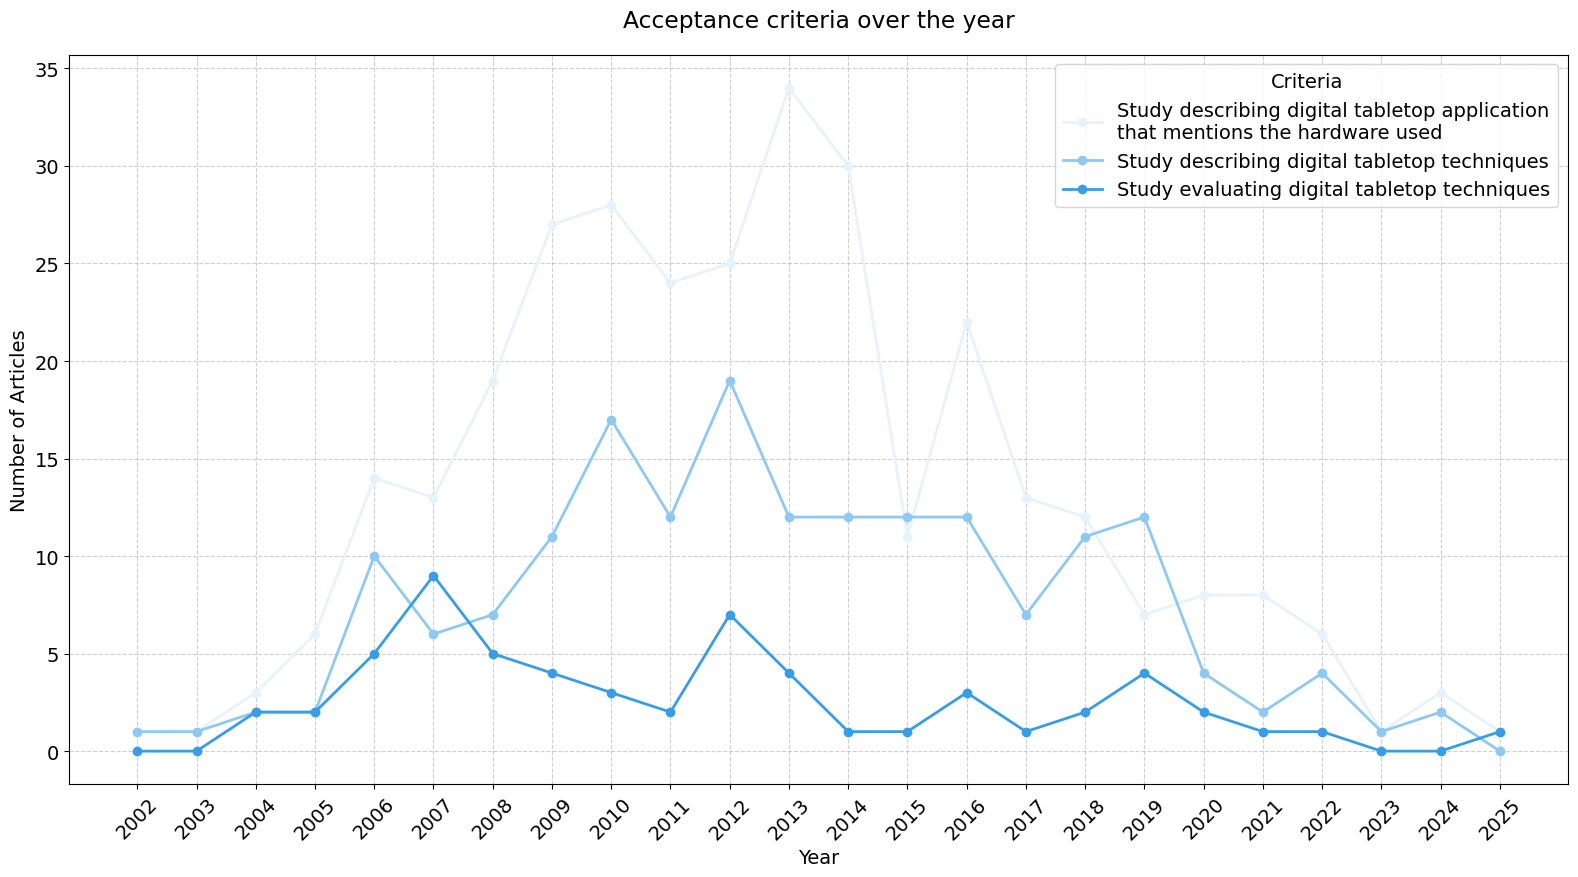

Processo concluído.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import textwrap

# --- Funções Auxiliares ---

plt.rcParams.update({'font.size': 14})

def get_status_color(status):
    """Retorna a cor base para cada status."""
    return {
        'Accepted': "#0785df",  # Azul
        'Rejected': '#d62728',  # Vermelho mais vibrante
        'Duplicated': '#ffcc00' # Amarelo
    }.get(status, '#999999')

def generate_color_palette(base_color, n_colors, start_lightness=0.2, end_lightness=0.9):
    """
    Gera n tons de uma cor base, com ajuste de luminosidade para melhor distinção.
    """
    colors = [base_color, 'white'] # Inverti para ter o tom mais escuro na base e clarear para o 'white'
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    # Ajuste o linspace para controlar a variação da luminosidade
    return [cmap(i) for i in np.linspace(end_lightness, start_lightness, n_colors)]


def create_pie_chart(status_counts, filename='pie_chart_accept_reject_status.png'):
    """Cria e salva o gráfico de pizza da distribuição por status."""
    fig, ax = plt.subplots(figsize=(10, 10))
    
    wedges, texts, autotexts = ax.pie(
        status_counts,
        labels=status_counts.index,
        colors=[get_status_color(s) for s in status_counts.index],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1},
        autopct=lambda p: f'{int(p * sum(status_counts)/100)}',
        pctdistance=0.85,
        textprops={'fontsize': 14, 'color': 'white', 'weight': 'bold'}
    )

    ax.set_title('Distribuição por Status', pad=20)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig) # Fechar a figura para liberar memória

def create_bar_chart(criteria_df, filename='bar_chart_accept_reject_criteria.png'):
    """Cria e salva o gráfico de barras empilhadas dos motivos por status."""
    fig, ax = plt.subplots(figsize=(14, 8))

    all_criteria = criteria_df.columns.tolist()
    n_criteria = len(all_criteria)

    # Gerar paleta para cada status
    status_palettes = {
        status: generate_color_palette(get_status_color(status), n_criteria)
        for status in criteria_df.index
    }

    x = np.arange(len(criteria_df.index))
    width = 0.8
    bottom = np.zeros(len(criteria_df.index))

    # Dicionário para mapear critério para a cor única da legenda
    legend_colors = {}
    
    # Plotar as barras empilhadas
    for j, criteria in enumerate(all_criteria):
        heights = criteria_df[criteria].values
        
        # Atribuir uma cor única para o critério, baseada no primeiro status que o contém
        if criteria not in legend_colors:
            # Encontra o primeiro status que tem esse critério para pegar a cor base
            for status_idx, status_name in enumerate(criteria_df.index):
                if criteria_df.loc[status_name, criteria] > 0:
                    legend_colors[criteria] = status_palettes[status_name][j]
                    break
            else: # Caso o critério não esteja em nenhum status com valor > 0, usar uma cor padrão
                legend_colors[criteria] = '#cccccc' # Cinza claro
                
        for i, status in enumerate(criteria_df.index):
            if heights[i] > 0:
                ax.bar(
                    x[i],
                    heights[i],
                    width,
                    bottom=bottom[i],
                    color=status_palettes[status][j], # Usar a cor específica para o status/critério
                    edgecolor='white',
                    linewidth=0.8
                )
        bottom += heights

    # Criar elementos da legenda
    legend_elements = [
        Patch(facecolor=legend_colors[criteria],
              edgecolor='white',
              label=textwrap.fill(criteria, width=40))
        for criteria in all_criteria
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(criteria_df.index)
    ax.set_title('Status According to Classification Criteria', pad=20)
    ax.set_ylabel('Number of Articles')
    ax.set_xlabel('Status')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True) # Coloca a grade atrás das barras

    # Adicionar legenda completa
    legend_elements.reverse()
    ax.legend(handles=legend_elements,
              title='Criteria',
              loc='upper right')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig) # Fechar a figura

def create_line_chart_criteria_over_time(articles_df, filename='line_chart_criteria_over_time.png'):
    """Cria e salva o gráfico de linha da evolução dos critérios de aceite/rejeite ao longo dos anos."""
    
    # Filtrar apenas os status 'Accepted' e 'Rejected'
    filtered_df = articles_df[articles_df['status'].isin(['Accepted', 'Rejected'])].copy()
    
    # Garantir que 'ano' é um número inteiro e ordenar por ano
    filtered_df['ano'] = filtered_df['ano'].astype(int)
    
    # Calcular a contagem de cada critério por ano
    # Usaremos pivot_table para reestruturar os dados facilmente
    criteria_over_time = filtered_df.pivot_table(
        index='ano',
        columns='selection_criteria',
        aggfunc='size',
        fill_value=0
    )
    
    # Remover colunas (critérios) que não são relevantes ou são NaN
    # Assumindo que 'selection_criteria' não tem NaN após a limpeza inicial
    # Se houver outros critérios que não sejam de aceite/rejeite e você não quer no gráfico de linha, filtre aqui.
    
    fig, ax = plt.subplots(figsize=(16, 9)) # Aumentei o tamanho para melhor visualização das linhas e legenda

    # Gerar a paleta de cores para os critérios
    # Reutiliza a lógica de cores do gráfico de barras para consistência
    all_criteria = criteria_over_time.columns.tolist()
    
    # É crucial que a ordem dos critérios aqui seja a mesma que a ordem usada para gerar a cor no bar_chart,
    # para que as cores correspondam. A maneira como 'legend_colors' é preenchida no bar_chart
    # garante uma cor única por critério. Vamos replicar isso.
    
    # Primeiro, obter todas as cores possíveis para os critérios (dos aceitos e rejeitados)
    # Replicamos o mapeamento de cores que fizemos no create_bar_chart para manter a consistência.
    # Você pode querer definir as cores para os critérios explicitamente se a ordem da paleta não for 1:1.
    
    # Mapeamento de cores para os critérios, baseado no que seria gerado para o bar chart
    temp_criteria_analysis = defaultdict(dict)
    for status in ['Accepted', 'Rejected']:
        subset = articles_df[articles_df['status'] == status]
        criteria_counts = subset['selection_criteria'].value_counts()
        for criteria, count in criteria_counts.items():
            if pd.notna(criteria):
                temp_criteria_analysis[status][criteria] = count
    
    temp_criteria_df = pd.DataFrame.from_dict(temp_criteria_analysis, orient='index').fillna(0)
    
    # Gerar a paleta de cores para cada status e então pegar as cores específicas dos critérios
    n_unique_criteria = len(all_criteria) # O número total de critérios no gráfico de linha
    
    status_palettes_for_line = {
        'Accepted': generate_color_palette(get_status_color('Accepted'), n_unique_criteria),
        'Rejected': generate_color_palette(get_status_color('Rejected'), n_unique_criteria)
    }

    line_chart_colors = {}
    for j, criteria in enumerate(all_criteria):
        # Tenta pegar a cor do critério de 'Accepted' primeiro, se presente
        if criteria in temp_criteria_df.columns and 'Accepted' in temp_criteria_df.index and temp_criteria_df.loc['Accepted', criteria] > 0:
            line_chart_colors[criteria] = status_palettes_for_line['Accepted'][j]
        # Caso contrário, tenta pegar de 'Rejected'
        elif criteria in temp_criteria_df.columns and 'Rejected' in temp_criteria_df.index and temp_criteria_df.loc['Rejected', criteria] > 0:
            line_chart_colors[criteria] = status_palettes_for_line['Rejected'][j]
        else:
            line_chart_colors[criteria] = '#808080' # Cor padrão para critérios sem ocorrências nos status filtrados

    # Plotar as linhas
    for criteria in all_criteria:
        if criteria in criteria_over_time.columns:
            ax.plot(
                criteria_over_time.index,
                criteria_over_time[criteria],
                label=textwrap.fill(criteria, width=45),
                color=line_chart_colors.get(criteria, '#808080'), # Usar a cor mapeada
                marker='o', # Marcadores para cada ponto no tempo
                linewidth=2
            )

    ax.set_title('Acceptance criteria over the year', pad=20)
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Articles')
    ax.set_xticks(criteria_over_time.index) # Mostra todos os anos com dados
    ax.tick_params(axis='x', rotation=45) # Rotaciona os labels do eixo X para melhor leitura
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Colocar a legenda fora do gráfico para não sobrepor as linhas
    ax.legend(title='Criteria')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# --- Script Principal ---

# Carregar os dados
try:
    articles_df = pd.read_csv('transformed_data.csv')
except FileNotFoundError:
    print("Erro: O arquivo 'transformed_data.csv' não foi encontrado. Certifique-se de que ele está no mesmo diretório do script.")
    exit()

# 1. Contar status
status_counts = articles_df['status'].value_counts()

# 2. Análise dos critérios de seleção para subdivisão
criteria_analysis = defaultdict(dict)

for status in ['Accepted', 'Rejected', 'Duplicated']:
    subset = articles_df[articles_df['status'] == status]
    criteria_counts = subset['selection_criteria'].value_counts()
    for criteria, count in criteria_counts.items():
        if pd.notna(criteria):
            criteria_analysis[status][criteria] = count

criteria_df = pd.DataFrame.from_dict(criteria_analysis, orient='index').fillna(0)

# Reordenar as colunas (critérios) para uma legenda mais organizada, se desejar
# Por exemplo, ordenar alfabeticamente ou por importância
# Exemplo de ordenação específica para "Rejected" se houver muitos critérios:
# rejected_criteria_order = criteria_df.loc['Rejected'].sort_values(ascending=False).index.tolist()
# all_criteria_ordered = [c for c in rejected_criteria_order if c in all_criteria] + \
#                        [c for c in all_criteria if c not in rejected_criteria_order]
# criteria_df = criteria_df[all_criteria_ordered]

print(status_counts)
display(criteria_df)

# 3. Gerar e salvar os gráficos
print("Gerando gráfico de pizza da distribuição por status...")
create_pie_chart(status_counts)

print("Gerando gráfico de barras dos motivos por status...")
create_bar_chart(criteria_df)

print("Gerando gráfico de linha da evolução dos critérios ao longo dos anos...")

articles_df = articles_df[articles_df['ano'] > 1990].copy()
articles_df = articles_df[articles_df['status'] == 'Accepted'].copy()

create_line_chart_criteria_over_time(articles_df) # Passa o DataFrame completo

print("Processo concluído.")

## Tecnologias de Display por ano

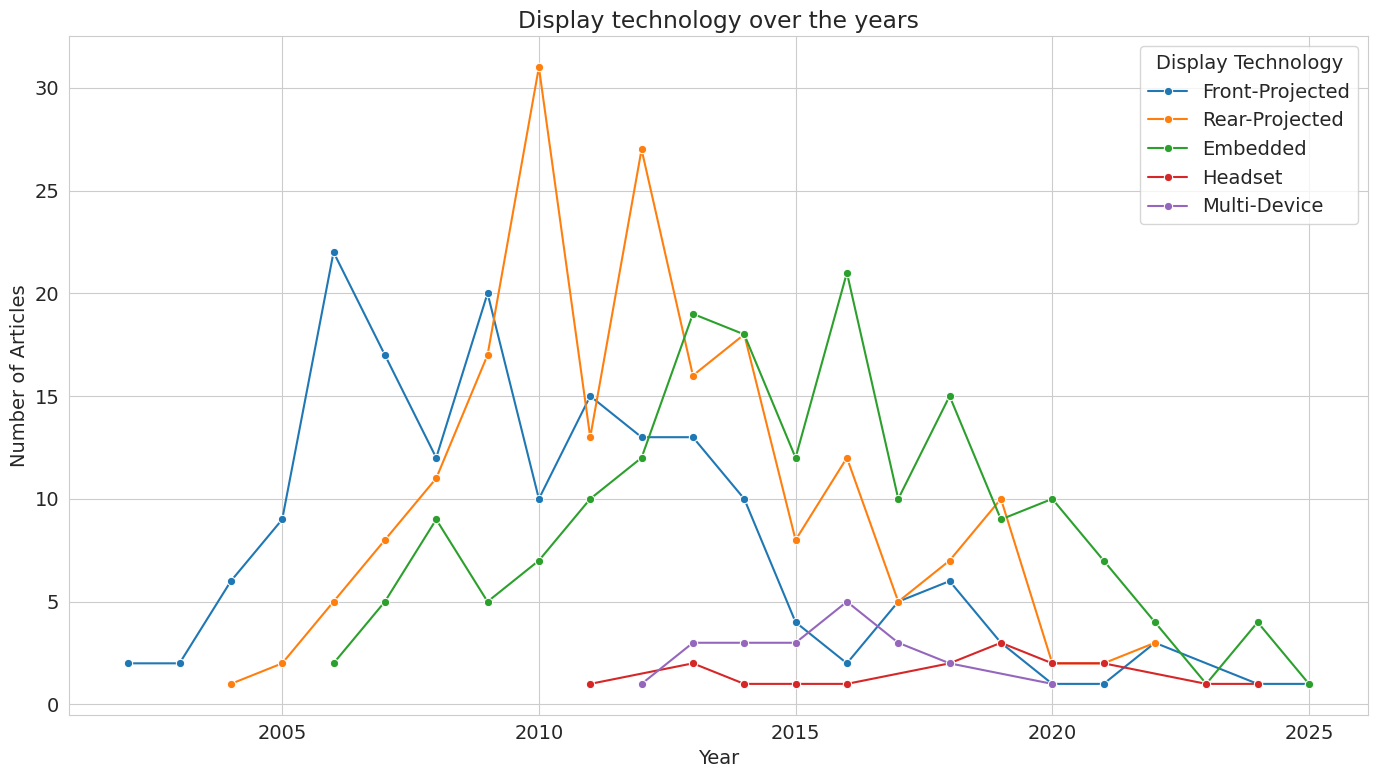

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})

# Carregar os dados
df = pd.read_csv("accepted_data_adapted.csv")
    
# Remover linhas com ano ou tecnologia do display ausente
df = df.dropna(subset=["ano", "Tecnologia do display"])

# Converter ano para inteiro
df["ano"] = df["ano"].astype(int)

# Separar as técnicas de display por vírgula e remover espaços em excesso
df["Tecnologia do display"] = df["Tecnologia do display"].str.split(",")

# Explodir as linhas com múltiplas técnicas em linhas separadas
df = df.explode("Tecnologia do display")

# Remover espaços em branco extras
df["Tecnologia do display"] = df["Tecnologia do display"].str.strip()

# Contar quantas vezes cada técnica aparece por ano
timeline = df.groupby(["ano", "Tecnologia do display"]).size().reset_index(name="count")

# Plotar o gráfico
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.lineplot(data=timeline, x="ano", y="count", hue="Tecnologia do display", marker="o")

# Ajustes finais
plt.title("Display technology over the years")
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.legend(title="Display Technology")
plt.tight_layout()
plt.savefig('display_tecnology_over_time.png', dpi=300)
plt.show()


## Input por ano

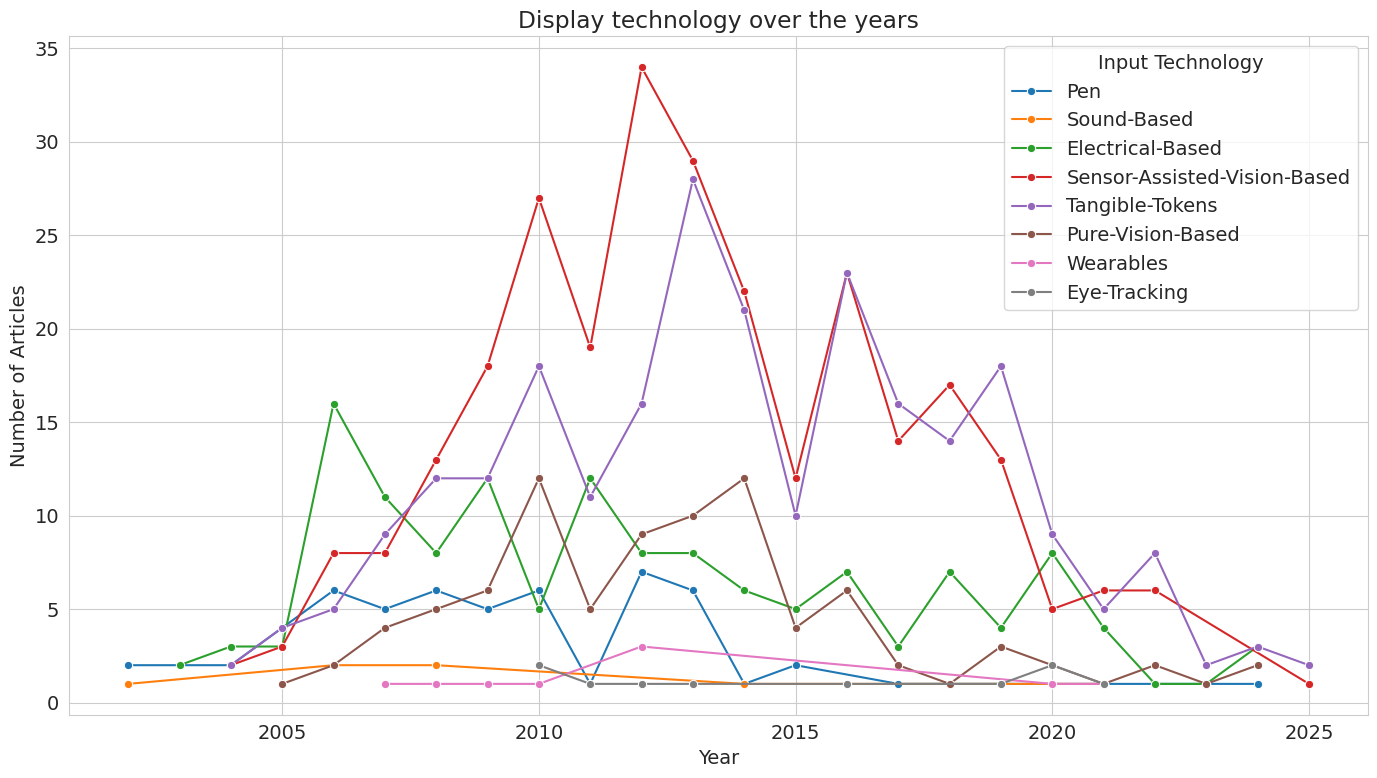

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})

# Carregar os dados
df = pd.read_csv("accepted_data_adapted.csv")

# Remover linhas com ano ou tecnologia do input ausente
df = df.dropna(subset=["ano", "Tecnologia do input"])

# Converter ano para inteiro
df["ano"] = df["ano"].astype(int)

# Separar as técnicas de input por vírgula e limpar espaços
df["Tecnologia do input"] = df["Tecnologia do input"].str.split(",")

# Explodir listas em linhas separadas
df = df.explode("Tecnologia do input")

# Remover espaços em branco extras
df["Tecnologia do input"] = df["Tecnologia do input"].str.strip()

# Contar ocorrências por ano e técnica
timeline_input = df.groupby(["ano", "Tecnologia do input"]).size().reset_index(name="count")

# Plotar
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.lineplot(data=timeline_input, x="ano", y="count", hue="Tecnologia do input", marker="o")

plt.title("Display technology over the years")
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.legend(title="Input Technology")
plt.tight_layout()
plt.savefig('input_tecnology_over_time.png', dpi=300)
plt.show()

## Suporte a interação ao longo dos anos

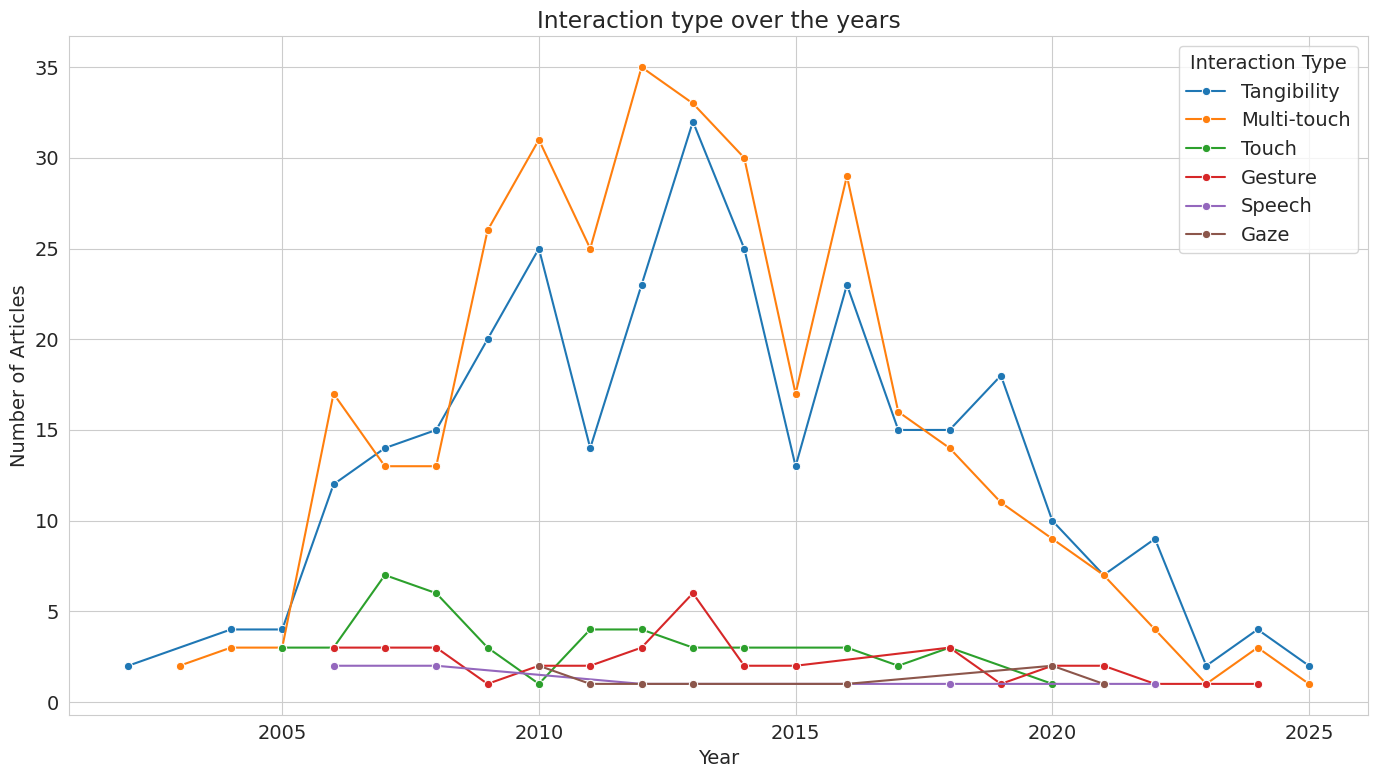

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})

# Carregar os dados
df = pd.read_csv("accepted_data_adapted.csv")

# Remover linhas com ano ou tipo de interação ausente
df = df.dropna(subset=["ano", "Tipo de interação"])

# Converter ano para inteiro
df["ano"] = df["ano"].astype(int)

# Separar os tipos de interação por vírgula e limpar espaços
df["Tipo de interação"] = df["Tipo de interação"].str.split(",")

# Explodir listas em linhas separadas
df = df.explode("Tipo de interação")

# Remover espaços em branco extras
df["Tipo de interação"] = df["Tipo de interação"].str.strip()

# Contar ocorrências por ano e tipo de interação
timeline_interacao = df.groupby(["ano", "Tipo de interação"]).size().reset_index(name="count")

# Plotar
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.lineplot(data=timeline_interacao, x="ano", y="count", hue="Tipo de interação", marker="o")

# Ajustes finais
plt.title("Interaction type over the years")
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.legend(title="Interaction Type")
plt.tight_layout()
plt.savefig('interaction_support_over_time.png', dpi=300)
plt.show()

## Colaboração


--- Análise de Suporte à Colaboração ---

Número de ocorrências por tipo de colaboração:
Suporte à colaboração
Co-located collaboration    468
Single user                  79
Remote collaboration         11
Name: count, dtype: int64

Percentagem de ocorrências por tipo de colaboração:
Suporte à colaboração
Co-located collaboration    83.87
Single user                 14.16
Remote collaboration         1.97
Name: count, dtype: float64
------------------------------------------


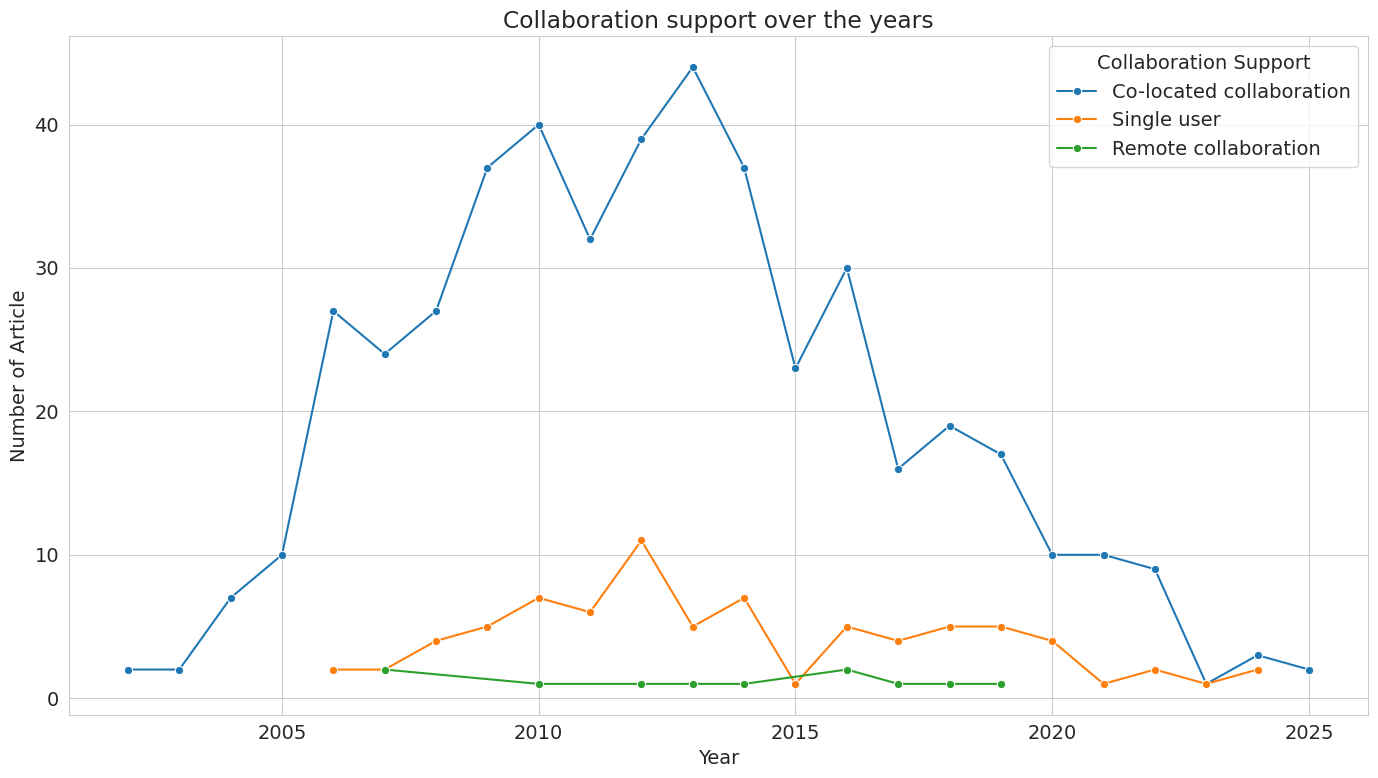

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})

# Carregar os dados
df = pd.read_csv("accepted_data_adapted.csv")

# Remover linhas com ano ou tipo de interação ausente
df = df.dropna(subset=["ano", "Suporte à colaboração"])

# Converter ano para inteiro
df["ano"] = df["ano"].astype(int)

df["Suporte à colaboração"] = df["Suporte à colaboração"].str.split(",")

# Explodir listas em linhas separadas
df = df.explode("Suporte à colaboração")

# Remover espaços em branco extras
df["Suporte à colaboração"] = df["Suporte à colaboração"].str.strip()

# Traduzir os termos para o inglês
translation_map = {
    'Colaboração presencial': 'Co-located collaboration',
    'Usuário único': 'Single user',
    'Colaboração remota': 'Remote collaboration'
}
df['Suporte à colaboração'] = df['Suporte à colaboração'].replace(translation_map)

print("\n--- Análise de Suporte à Colaboração ---")
collaboration_counts = df["Suporte à colaboração"].value_counts()
total_collaborations = collaboration_counts.sum()

print("\nNúmero de ocorrências por tipo de colaboração:")
print(collaboration_counts)

print("\nPercentagem de ocorrências por tipo de colaboração:")
collaboration_percentages = (collaboration_counts / total_collaborations) * 100
print(collaboration_percentages.round(2))
print("------------------------------------------")

# Contar ocorrências por ano e Suporte à colaboração
timeline_interacao = df.groupby(["ano", "Suporte à colaboração"]).size().reset_index(name="count")

# Plotar
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.lineplot(data=timeline_interacao, x="ano", y="count", hue="Suporte à colaboração", marker="o")

# Ajustes finais
plt.title("Collaboration support over the years")
plt.xlabel("Year")
plt.ylabel("Number of Article")
plt.legend(title="Collaboration Support")
plt.tight_layout()
plt.savefig('collaboration_support_over_time.png', dpi=300)
plt.show()

## Modelos específicos

Número de artigos que mencionaram o modelo da mesa: 275

-------------------------------------


/tmp/ipykernel_22435/4263644997.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  modelo_por_ano_filtrado["Usa modelo com nome?"] = pd.Categorical(


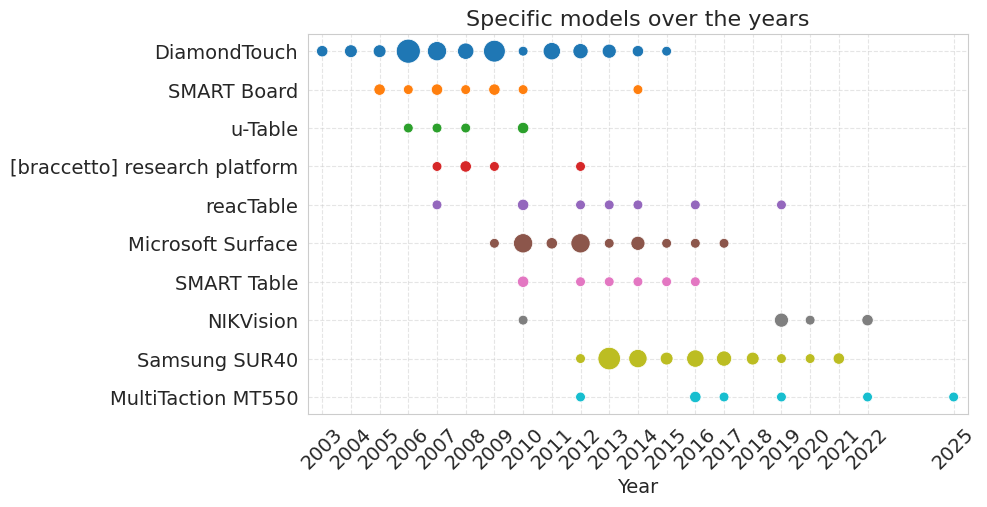

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})

# Carregar dados
df = pd.read_csv("accepted_data_adapted.csv")

# Limpar a coluna de ano
df["ano"] = pd.to_numeric(df["ano"], errors="coerce").dropna().astype(int)

# Filtrar onde há modelos com nome
df_modelos = df.dropna(subset=["Usa modelo com nome?"]).copy()

num_artigos_com_modelo = len(df_modelos)
print(f"Número de artigos que mencionaram o modelo da mesa: {num_artigos_com_modelo}")
print("\n-------------------------------------")

# Normalizar: manter só o nome antes do '+' (ex: "DiamondTouch + Pen" -> "DiamondTouch")
df_modelos["Usa modelo com nome?"] = (
    df_modelos["Usa modelo com nome?"]
    .str.split("+", n=1)
    .str[0]
    .str.strip()
)

# Contagem por modelo e ano
modelo_por_ano = df_modelos.groupby(["Usa modelo com nome?", "ano"]).size().reset_index(name="count")

# Contar total de ocorrências por modelo
modelo_total = modelo_por_ano.groupby("Usa modelo com nome?")["count"].sum()

# Manter apenas modelos com mais de 5 ocorrências no total
modelos_filtrados = modelo_total[modelo_total > 4].index

# Filtrar os dados
modelo_por_ano_filtrado = modelo_por_ano[modelo_por_ano["Usa modelo com nome?"].isin(modelos_filtrados)]

# Ordenar modelos por ano mais antigo
ordem_modelos = (
    modelo_por_ano_filtrado
    .groupby("Usa modelo com nome?")["ano"]
    .min()
    .sort_values()
    .index.tolist()
)

# Aplicar ordem como categoria ordenada
modelo_por_ano_filtrado["Usa modelo com nome?"] = pd.Categorical(
    modelo_por_ano_filtrado["Usa modelo com nome?"], categories=ordem_modelos, ordered=True
)

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=modelo_por_ano_filtrado,
    x="ano",
    y="Usa modelo com nome?",
    size="count",
    hue="Usa modelo com nome?",
    legend=False,
    sizes=(50, 300),
)

plt.title("Specific models over the years", fontsize=16)
plt.xlabel("Year")
plt.ylabel("")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.xticks(sorted(modelo_por_ano_filtrado["ano"].unique()), rotation=45)
plt.xlim(
    modelo_por_ano_filtrado["ano"].min() - 0.5,
    modelo_por_ano_filtrado["ano"].max() + 0.5
)
plt.savefig('models_over_time.png', dpi=300)
plt.show()


## Tamanho da tela

Número de artigos que mencionaram o tamanho da mesa: 275

-------------------------------------
Maior tamanho encontrado: 169

--- Estatísticas de Tamanho da Mesa ---

5 tamanhos mais comuns:
Tamanho da mesa
42    84
40    48
30    33
55    23
46    18
Name: count, dtype: int64

Média de tamanho: 45.88 polegadas
Mediana de tamanho: 42.00 polegadas

-------------------------------------


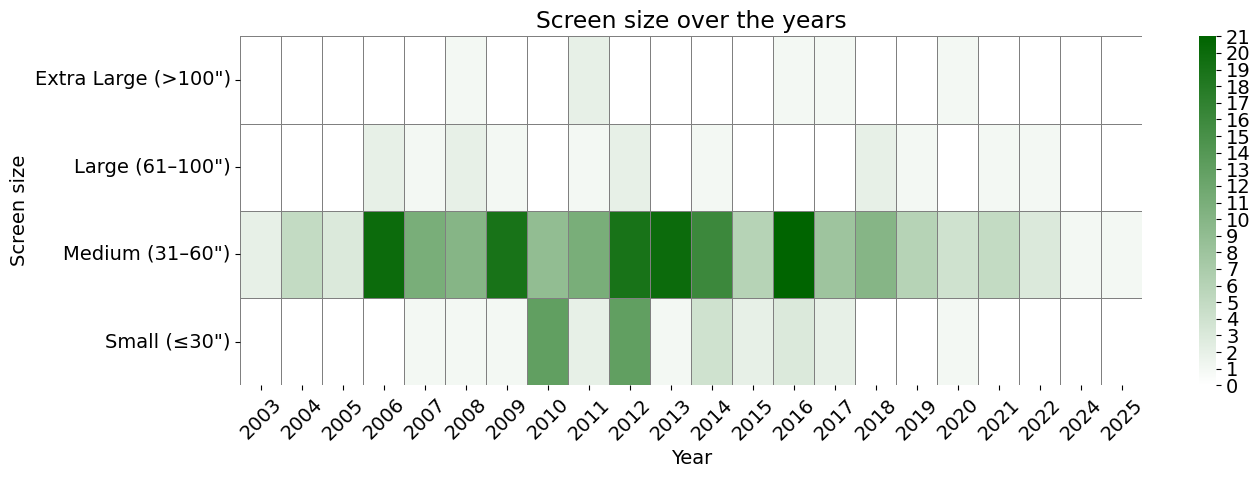

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({'font.size': 14})

# Carregar e limpar dados
df = pd.read_csv("transformed_data.csv")
df = df.dropna(subset=["ano", "Tamanho da mesa"])
df["ano"] = df["ano"].astype(int)
df["Tamanho da mesa"] = df["Tamanho da mesa"].str.replace(r'["”’’″]', '', regex=True).str.strip()
df["Tamanho da mesa"] = pd.to_numeric(df["Tamanho da mesa"])
df = df.dropna(subset=["Tamanho da mesa"])

num_artigos_com_tamanho = len(df)
print(f"Número de artigos que mencionaram o tamanho da mesa: {num_artigos_com_tamanho}")
print("\n-------------------------------------")

# Arredondar para inteiro
df["Tamanho da mesa"] = df["Tamanho da mesa"].round(0).astype(int)

# Mostrar o maior valor
print("Maior tamanho encontrado:", df["Tamanho da mesa"].max())

# --- Adições para imprimir as estatísticas ---

print("\n--- Estatísticas de Tamanho da Mesa ---")

# 5 tamanhos mais comuns
print("\n5 tamanhos mais comuns:")
print(df["Tamanho da mesa"].value_counts().head(5))

# Média de tamanho
media_tamanho = df["Tamanho da mesa"].mean()
print(f"\nMédia de tamanho: {media_tamanho:.2f} polegadas")

# Mediana de tamanho
mediana_tamanho = df["Tamanho da mesa"].median()
print(f"Mediana de tamanho: {mediana_tamanho:.2f} polegadas")

print("\n-------------------------------------")

# --- Fim das adições ---

# Criar faixas de tamanho
def categorizar_tamanho(t):
    if t <= 30:
        return "Small (≤30\")"
    elif t <= 60:
        return "Medium (31–60\")"
    elif t <= 100:
        return "Large (61–100\")"
    else:
        return "Extra Large (>100\")"

df["Faixa de Tamanho"] = df["Tamanho da mesa"].apply(categorizar_tamanho)

# Agrupar por faixa e ano
faixa_heatmap = df.groupby(["Faixa de Tamanho", "ano"]).size().unstack(fill_value=0)

# Manter a ordem das faixas
faixa_order = ["Extra Large (>100\")", "Large (61–100\")", "Medium (31–60\")", "Small (≤30\")"]
faixa_heatmap = faixa_heatmap.reindex(index=faixa_order, fill_value=0)

cmap_branco_verde = LinearSegmentedColormap.from_list("branco_verde", ["#ffffff", "#006400"])

# Plotar heatmap por faixas
plt.figure(figsize=(14, 5))
ax2 = sns.heatmap(
    faixa_heatmap,
    cmap=cmap_branco_verde,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"ticks": np.arange(0, faixa_heatmap.values.max() + 1)},
)
ax2.collections[0].colorbar.set_ticks(np.arange(0, faixa_heatmap.values.max() + 1))
plt.title("Screen size over the years") # Adicionei um título ao heatmap
plt.xlabel("Year") # Adicionei rótulo ao eixo X
plt.ylabel("Screen size") # Adicionei rótulo ao eixo Y
plt.tick_params(axis='x', rotation=45) # Rotaciona os labels do eixo X para melhor leitura
plt.tight_layout()
plt.savefig('display_size_over_time.png', dpi=300)
plt.show()